# Preprocessing mengggunakan dan Ekstraksi Fitur
Notebook ini telah dirapikan agar setiap polutan memiliki alur preprocessing dan ekstraksi fiturnya masing-masing.


## CO


In [68]:
import pandas as pd
df = pd.read_csv("CO.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing (CO): {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing (CO): 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [69]:
df = pd.read_csv("CO.csv")
missing_value = df['CO'].isna().sum()
print(f"Jumlah missing value pada kolom CO: {missing_value}")

Jumlah missing value pada kolom CO: 59


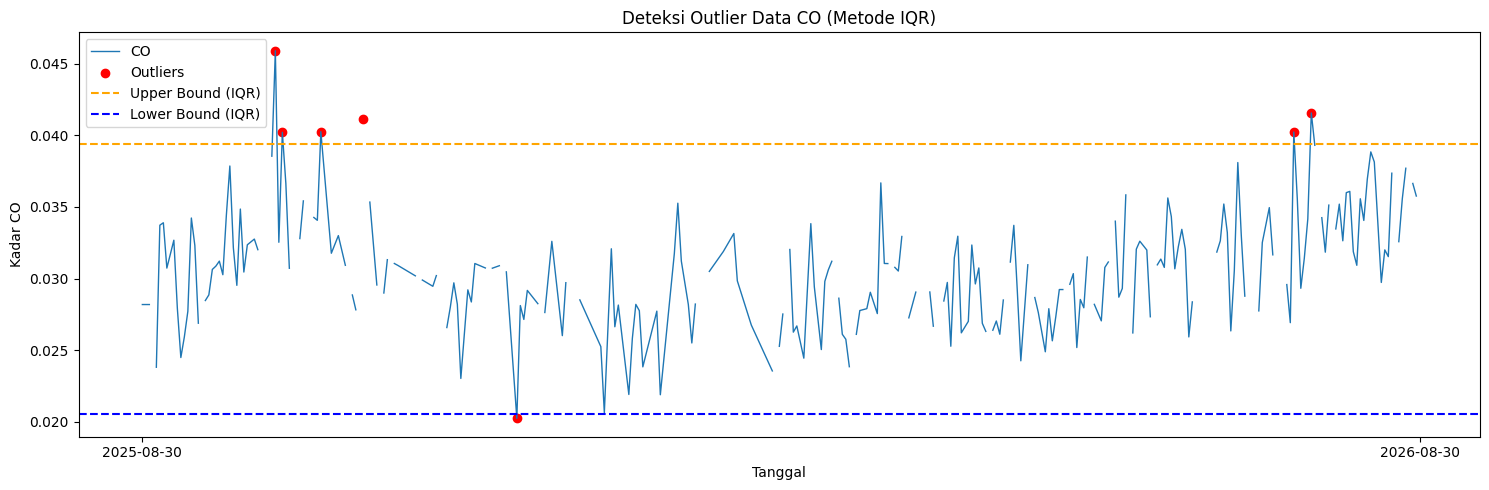

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['CO'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [76]:
df['CO_filled'] = df['CO'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['CO_filled'].quantile(0.25)
    Q3 = df['CO_filled'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. Deteksi lokasi outlier
    outliers = (df['CO_filled'] < lower_bound) | (df['CO_filled'] > upper_bound)
    
    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break
    
    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan polinomial + bfill + ffill
    df['CO_filled'] = df['CO_filled'].mask(outliers)
    df['CO_filled'] = df['CO_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_co = pd.DataFrame({"date": df['date'], "CO": df['CO_filled']})
df_co.to_csv("CO_filed_polynomial.csv", index=False)

print("Data CO berhasil disimpan ke CO_filed_polynomial.csv")

Data CO berhasil disimpan ke CO_filed_polynomial.csv


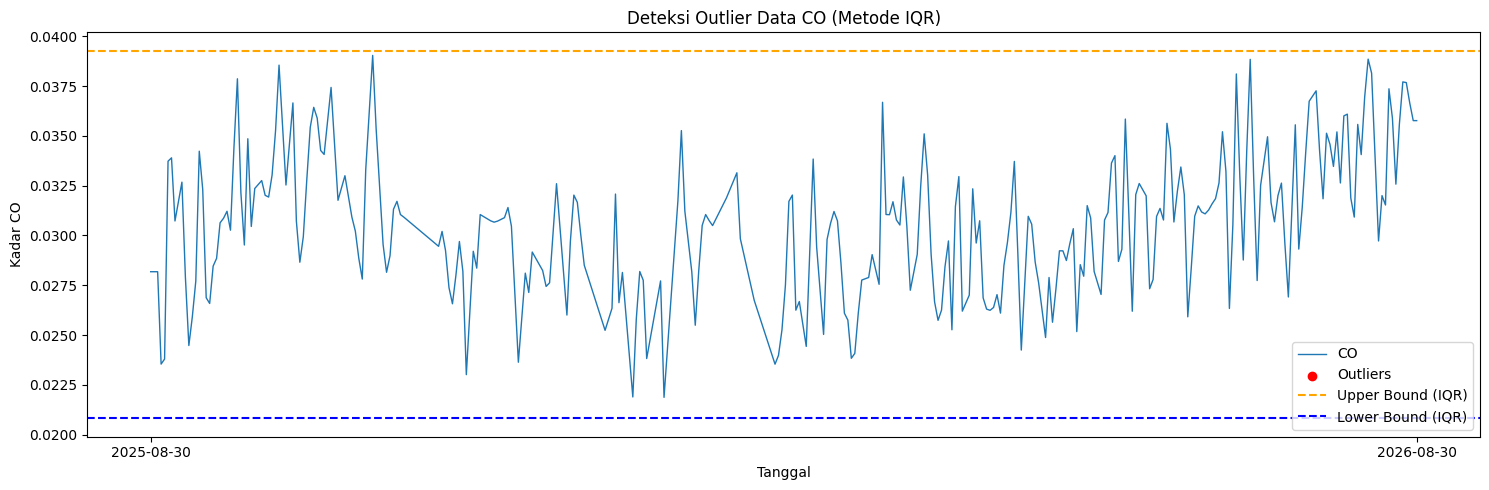

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_filed_polynomial.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['CO'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

## SO2


In [40]:
import pandas as pd
df = pd.read_csv("SO2.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing (SO2): {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing (SO2): 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [41]:
df = pd.read_csv("SO2.csv")
missing_value = df['SO2'].isna().sum()
print(f"Jumlah missing value pada kolom SO2: {missing_value}")

Jumlah missing value pada kolom SO2: 41


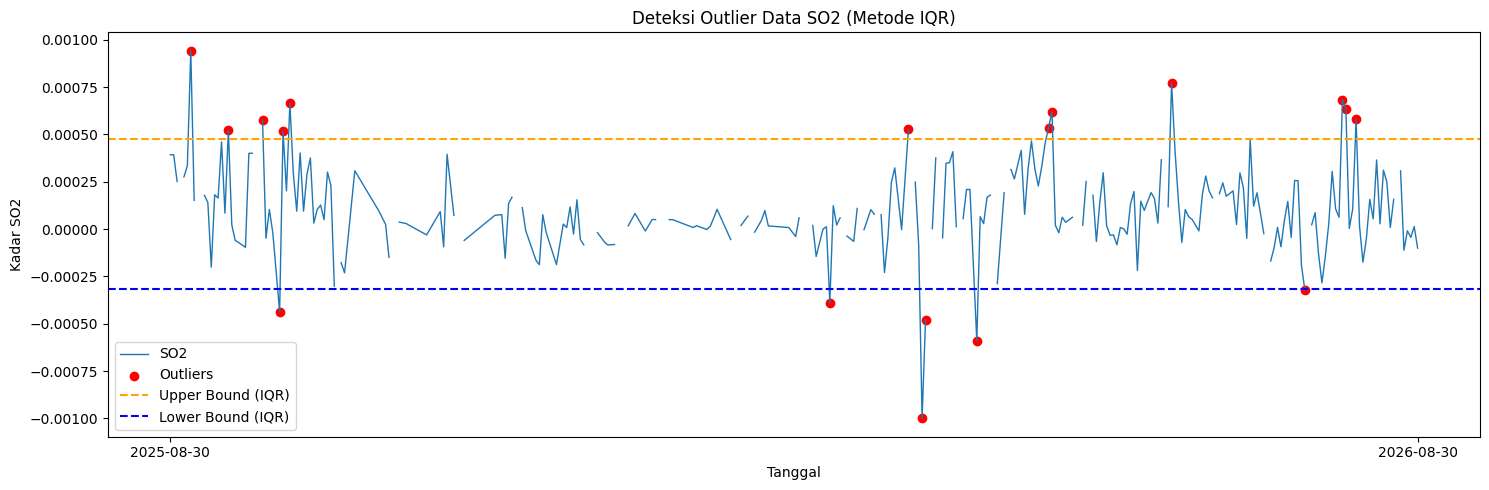

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [82]:
df['SO2_cleaned'] = df['SO2'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['SO2_cleaned'].quantile(0.25)
    Q3 = df['SO2_cleaned'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. Deteksi lokasi outlier
    outliers = (df['SO2_cleaned'] < lower_bound) | (df['SO2_cleaned'] > upper_bound)
    
    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break
    
    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan polinomial + bfill + ffill
    df['SO2_cleaned'] = df['SO2_cleaned'].mask(outliers)
    df['SO2_cleaned'] = df['SO2_cleaned'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_so2 = pd.DataFrame({"date": df['date'], "SO2": df['SO2_cleaned']})
df_so2.to_csv("SO2_filed_polynomial.csv", index=False)

print("Data SO2 berhasil disimpan ke SO2_filed_polynomial.csv")

Data SO2 berhasil disimpan ke SO2_filed_polynomial.csv


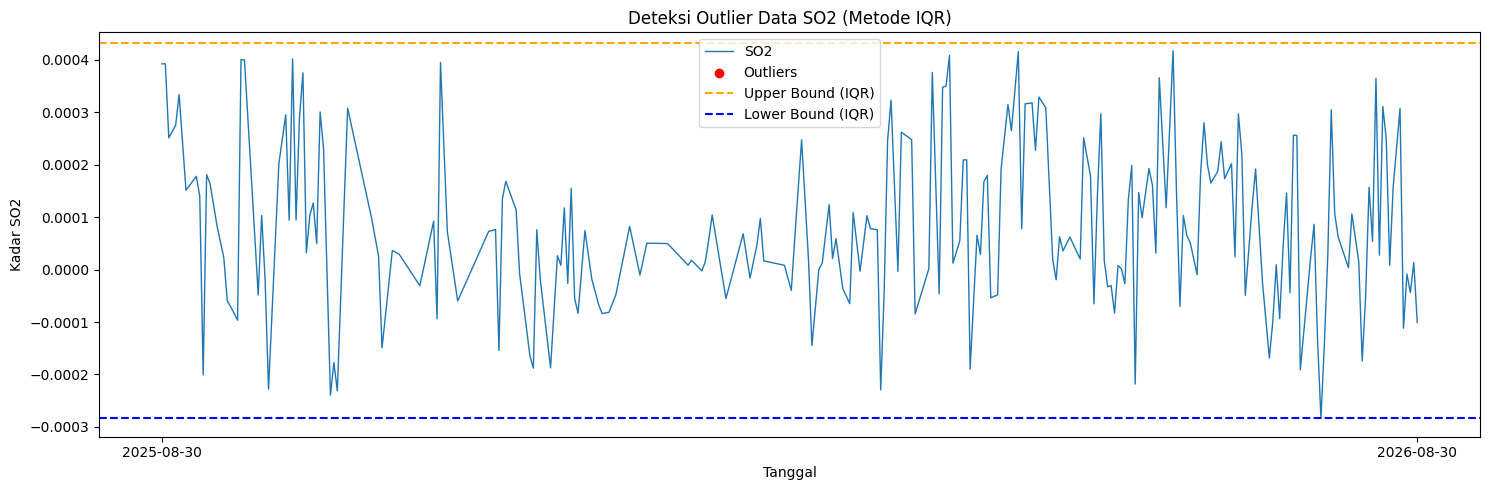

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_filed_polynomial.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

## NO2


In [105]:
import pandas as pd
df = pd.read_csv("NO2.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing (NO2): {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing (NO2): 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [106]:
df = pd.read_csv("NO2.csv")
missing_value = df['NO2'].isna().sum()
print(f"Jumlah missing value pada kolom NO2: {missing_value}")

Jumlah missing value pada kolom NO2: 62


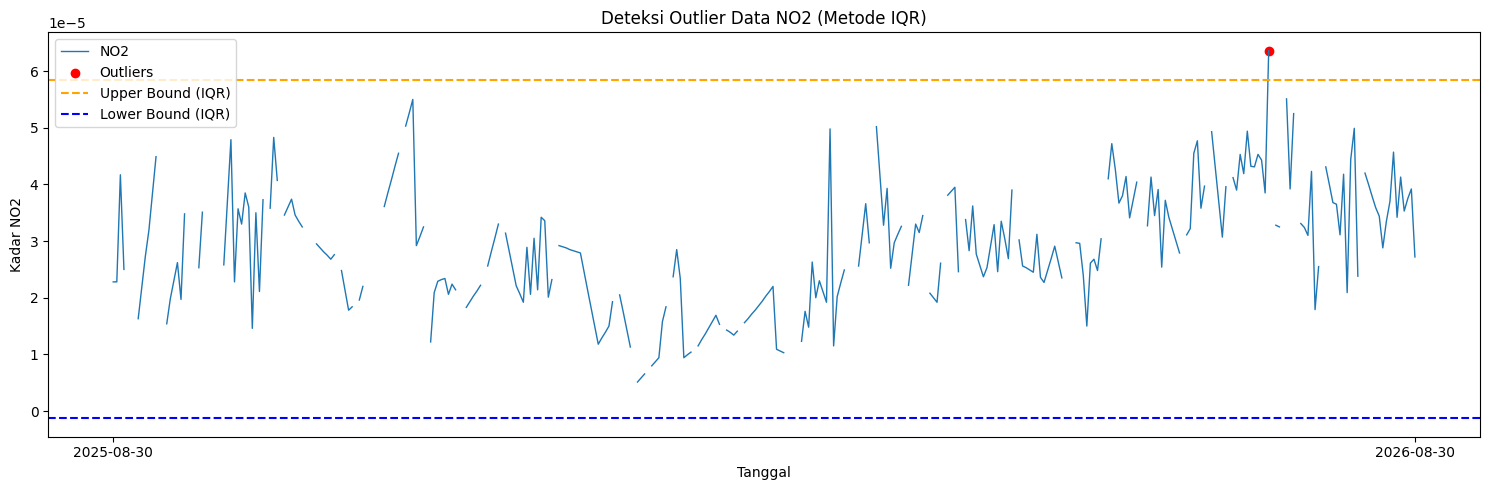

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [85]:
df['NO2_cleaned'] = df['NO2'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['NO2_cleaned'].quantile(0.25)
    Q3 = df['NO2_cleaned'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. Deteksi lokasi outlier
    outliers = (df['NO2_cleaned'] < lower_bound) | (df['NO2_cleaned'] > upper_bound)
    
    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break
    
    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan polinomial + bfill + ffill
    df['NO2_cleaned'] = df['NO2_cleaned'].mask(outliers)
    df['NO2_cleaned'] = df['NO2_cleaned'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_no2 = pd.DataFrame({"date": df['date'], "NO2": df['NO2_cleaned']})
df_no2.to_csv("NO2_filed_polynomial.csv", index=False)

print("Data NO2 berhasil disimpan ke SO2_filed_polynomial.csv")

Data NO2 berhasil disimpan ke SO2_filed_polynomial.csv


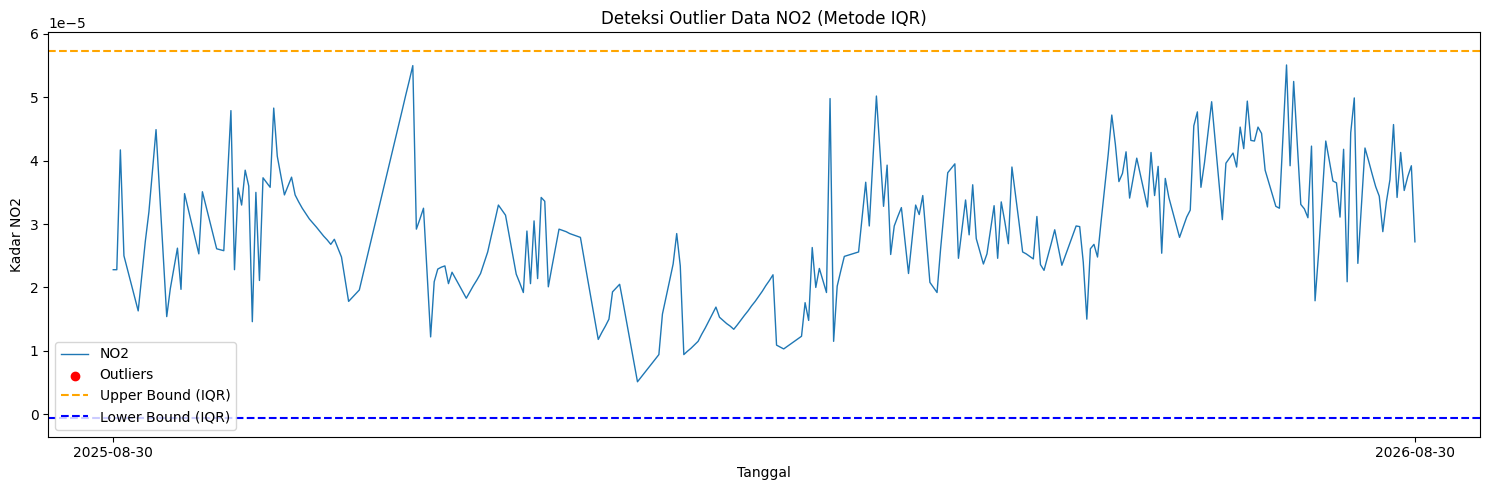

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_filed.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [87]:
import pandas as pd

df_co = pd.read_csv("CO_filed_polynomial.csv")
df_no2 = pd.read_csv("NO2_filed_polynomial.csv")
df_so2 = pd.read_csv("SO2_filed_polynomial.csv")

dataframe_merged = pd.DataFrame({
    "date": df_no2['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Nganjuk_polynomial.csv", index=False)

In [88]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
# Sesuaikan nama file jika berbeda (misal: 'mystorage/Kerek-Clean.csv')
df = pd.read_csv('Polutan_Nganjuk_polynomial.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

# ---------- 2. Daftar PERSIS 68 fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


# Dictionary untuk menampung seluruh hasil ekstraksi dari semua polutan
combined_row = {}

# ---------- 3. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")
    
    # Buat copy dataframe agar tidak saling menimpa
    df_poly = df[['date', pollutant]].copy()

    # Paksa kolom target jadi numerik
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')
    n_missing_before = df_poly[pollutant].isna().sum()
    print(f"Jumlah NaN/non-numerik pada {pollutant}: {n_missing_before}")

    # Handling outlier dengan IQR
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    # Interpolasi waktu dan cleaning
    df_clean = df_poly.set_index('date').interpolate(method='time').ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 4. Simpan ke DataFrame final (1 baris, 204 kolom) ----------
extracted_features_final = pd.DataFrame([combined_row])

print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = 'Baron_Polynomial.csv'
extracted_features_final.to_csv(output_filename, index=False)
print(f"File berhasil disimpan sebagai: {output_filename}")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 0

--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 0

--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 0

Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: Baron_Polynomial.csv
